# Sprint 3: Optimization & Final Model

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,  r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
import joblib

In [3]:
X_train = pd.read_csv("/Users/rezwanshehik/Downloads/X_train_final.csv")
X_test  = pd.read_csv("/Users/rezwanshehik/Downloads/X_test_final.csv")
y_train = pd.read_csv("/Users/rezwanshehik/Downloads/y_train.csv").squeeze()
y_test  = pd.read_csv("/Users/rezwanshehik/Downloads/y_test.csv").squeeze()

In [4]:
X_train.shape

(12000, 20)

In [5]:
X_test.shape

(3000, 20)

In [6]:
X_train.columns

Index(['job_title', 'salary_currency', 'experience_level', 'employment_type',
       'company_location', 'company_size', 'employee_residence',
       'remote_ratio', 'education_required', 'years_experience', 'industry',
       'job_description_length', 'benefits_score', 'application_duration',
       'posting_month', 'posting_year', 'posting_day', 'day_of_week',
       'days_to_apply', 'skills_count'],
      dtype='object')

In [7]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    y_train_pred = model.predict(X_tr)
    y_test_pred  = model.predict(X_te)
    train_r2  = r2_score(y_tr, y_train_pred)
    test_r2   = r2_score(y_te, y_test_pred)
    train_mae = mean_absolute_error(y_tr, y_train_pred)
    test_mae  = mean_absolute_error(y_te, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_tr, y_train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_te, y_test_pred))
    r2_gap = train_r2 - test_r2
    return {
        'Model'       : name,
        'Train R²'    : round(train_r2,   4),
        'Test R²'     : round(test_r2,    4),
        'Train RMSE'  : round(train_rmse, 2),
        'Test RMSE'   : round(test_rmse,  2),
        'Train MAE'   : round(train_mae,  2),
        'Test MAE'    : round(test_mae,   2),
        'R² Gap'      : round(r2_gap,     4),
        'Overfitting?': 'Overfit' if r2_gap > 0.1 else 'Good'
    }
print('evaluate_model() helper defined!')

evaluate_model() helper defined!


---
# Step 1: Feature Engineering
> Create new features from existing ones to give the model more signal.

| Type | Example |
|------|---------|
| **Ratios** | experience_per_age |
| **Aggregations** | total_experience_flag |
| **Domain-specific** | senior_flag, high_edu_flag |

### We Work on copies so original data stays clean 

In [8]:
X_train_fe = X_train.copy()
X_test_fe  = X_test.copy()

print('Current features:', list(X_train_fe.columns))
print(f'   Shape before FE : {X_train_fe.shape}')

Current features: ['job_title', 'salary_currency', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'education_required', 'years_experience', 'industry', 'job_description_length', 'benefits_score', 'application_duration', 'posting_month', 'posting_year', 'posting_day', 'day_of_week', 'days_to_apply', 'skills_count']
   Shape before FE : (12000, 20)


## 1. Ratio: years_experience per unit of age (proxy for 'early starter')

In [9]:
for df in [X_train_fe, X_test_fe]:
    
     if 'years_experience' in df.columns and 'age' in df.columns:
        df['exp_per_age'] = df['years_experience'] / (df['age'] + 1)   # +1 avoids div/0

## 2. Seniority flag — senior if experience > 5 years

In [10]:
 if 'years_experience' in df.columns:
        df['senior_flag'] = (df['years_experience'] > 5).astype(int)

print(f'   New features     : {[c for c in X_train_fe.columns if c not in X_train.columns]}')

   New features     : []


## 3. High education flag — if education_level >= 3 (adjust threshold to your encoding)

In [11]:
 if 'education_level' in df.columns:
        df['high_edu_flag'] = (df['education_level'] >= 3).astype(int)

## 4. Aggregation: experience × job_level interaction

In [12]:
  if 'years_experience' in df.columns and 'job_level' in df.columns:
        df['exp_x_level'] = df['years_experience'] * df['job_level']

In [13]:
print(f'   Feature Engineering done!')
print(f'   Shape after  FE : {X_train_fe.shape}')

   Feature Engineering done!
   Shape after  FE : (12000, 20)


In [14]:
X_train_fe.head(3)

,job_title,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,job_description_length,benefits_score,application_duration,posting_month,posting_year,posting_day,day_of_week,days_to_apply,skills_count
0,0.003399,-2.261256,-0.445200,0.573224,-0.181799,1.234367,0.516249,-1.206612,-0.441457,-0.762152,-0.239714,0.192669,-0.411952,1.695907,0.419900,-0.566700,0.366307,0.505220,1.695907,0.007951
1,1.575214,0.505698,0.450725,-1.072690,1.494300,-1.216598,1.377205,-1.206612,0.452030,-0.218426,0.559123,-0.393901,-0.826906,0.773265,1.848779,-0.566700,1.162463,0.005991,0.773265,-1.215304
2,0.258288,0.505698,-1.341125,-0.866951,-0.477582,0.008885,0.478816,-1.206612,0.452030,-1.124635,0.096638,-0.270321,1.524501,-1.129683,-1.008979,1.764601,1.276200,0.005991,-1.129683,1.231207


# Step 2: Feature Selection
> Remove irrelevant or redundant features to reduce noise and improve generalization.

We use **3 methods**:
1. **Correlation Matrix** — remove highly correlated features (multicollinearity)
2. **Feature Importance** — keep only features that matter to the model
3. **Recursive Feature Elimination (RFE)** — systematically select the best subset

## Correlation Matrix

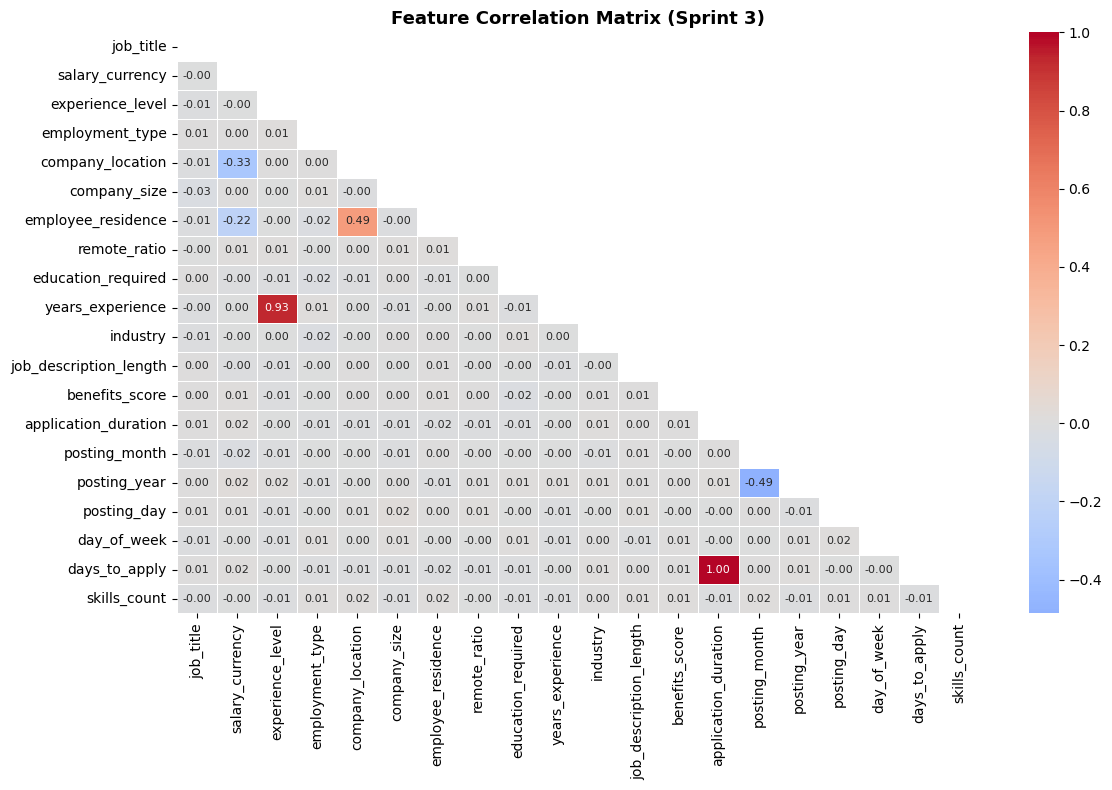

  Highly correlated pairs (|r| > 0.85):
   experience_level ↔ years_experience  →  r = 0.926
   application_duration ↔ days_to_apply  →  r = 1.0


In [15]:
plt.figure(figsize=(12, 8))
corr_matrix = X_train_fe.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Feature Correlation Matrix (Sprint 3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify highly correlated pairs (|r| > 0.85)
upper = corr_matrix.where(mask == False)
high_corr = [(col, row, round(upper.loc[row, col], 3))
             for col in upper.columns
             for row in upper.index
             if abs(upper.loc[row, col]) > 0.85]
print('  Highly correlated pairs (|r| > 0.85):')
for a, b, r in high_corr:
    print(f'   {a} ↔ {b}  →  r = {r}')
if not high_corr:
    print('   None found — all features are sufficiently independent')

### Drop one feature from each highly correlated pair

In [16]:
to_drop_corr = [pair[1] for pair in high_corr]   # drop the second in each pair
X_train_fs = X_train_fe.drop(columns=to_drop_corr, errors='ignore')
X_test_fs  = X_test_fe.drop(columns=to_drop_corr, errors='ignore')
print(f' Dropped correlated features: {to_drop_corr if to_drop_corr else "none"}')
print(f'   Features remaining : {X_train_fs.shape[1]}')

 Dropped correlated features: ['years_experience', 'days_to_apply']
   Features remaining : 18


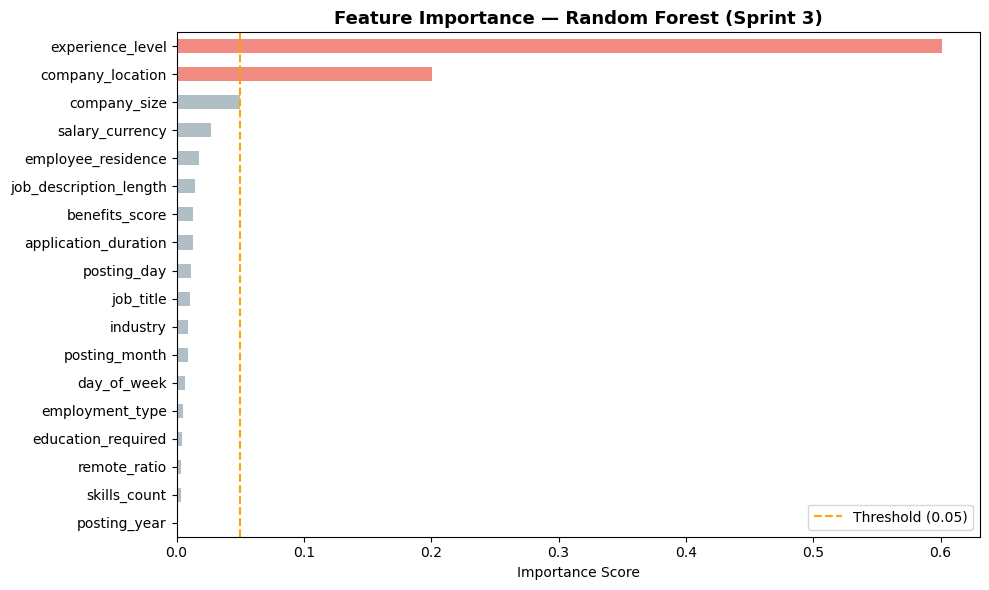

Top 5 features:
experience_level      0.600862
company_location      0.200872
company_size          0.049651
salary_currency       0.026841
employee_residence    0.017321
 Selected 10 important features: ['job_title', 'posting_day', 'application_duration', 'benefits_score', 'job_description_length', 'employee_residence', 'salary_currency', 'company_size', 'company_location', 'experience_level']


In [17]:
rf_fs = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_fs.fit(X_train_fs, y_train)

feat_imp = pd.Series(rf_fs.feature_importances_, index=X_train_fs.columns)
feat_imp = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#F28B82' if v > 0.15 else '#4A90D9' if v > 0.05 else '#B0BEC5'
          for v in feat_imp.values]
feat_imp.plot(kind='barh', color=colors)
plt.axvline(0.05, color='orange', linestyle='--', label='Threshold (0.05)')
plt.title('Feature Importance — Random Forest (Sprint 3)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(feat_imp.sort_values(ascending=False).head(5).to_string())

# Keep features with importance > 0.01
important_features = feat_imp[feat_imp > 0.01].index.tolist()
print(f' Selected {len(important_features)} important features: {important_features}')

In [18]:
X_train_imp = X_train_fs[important_features]
X_test_imp  = X_test_fs[important_features]
print(f'Shape after importance filtering: {X_train_imp.shape}')

Shape after importance filtering: (12000, 10)


## Recursive Feature Elimination (RFE)

In [19]:
# RFE: automatically finds the best N features
n_features_to_select = max(3, len(important_features) // 2 + 1)  # select top half

rfe = RFE(estimator=RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
          n_features_to_select=n_features_to_select)
rfe.fit(X_train_imp, y_train)

rfe_features = X_train_imp.columns[rfe.support_].tolist()
print(f'RFE selected {len(rfe_features)} features:')
for f in rfe_features:
    print(f'   • {f}')

X_train_rfe = X_train_imp[rfe_features]
X_test_rfe  = X_test_imp[rfe_features]

RFE selected 6 features:
   • application_duration
   • benefits_score
   • job_description_length
   • company_size
   • company_location
   • experience_level


## Quick baseline comparison — RF on original vs RFE features

In [20]:
rf_orig = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_orig.fit(X_train, y_train)
r2_orig = r2_score(y_test, rf_orig.predict(X_test))

rf_rfe = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_rfe.fit(X_train_rfe, y_train)
r2_rfe = r2_score(y_test, rf_rfe.predict(X_test_rfe))

print(f'RF on original features  → Test R² = {r2_orig:.4f}')
print(f'RF on RFE features       → Test R² = {r2_rfe:.4f}')
print()

RF on original features  → Test R² = 0.8796
RF on RFE features       → Test R² = 0.8558



## Using the better feature set going forward

In [21]:
if r2_rfe >= r2_orig:
    X_train_best = X_train_rfe
    X_test_best  = X_test_rfe
    best_features = rfe_features
    print('Using RFE features (equal or better performance)')
else:
    X_train_best = X_train
    X_test_best  = X_test
    best_features = list(X_train.columns)
    print('Using original features (they perform better)')

Using original features (they perform better)


#  Step 3: Hyperparameter Tuning
> Find the optimal model settings using **GridSearchCV** (exhaustive) and **RandomizedSearchCV** (fast).

| Method | How it works | Best for |
|--------|-------------|----------|
| **GridSearchCV** | Tries every combination | Small param grids |
| **RandomizedSearchCV** | Samples random combinations | Large param grids |


## RandomizedSearchCV — Random Forest (Fast Tuning)

In [22]:
from scipy.stats import randint

param_dist_rf = {
    'n_estimators'     : randint(100, 500),
    'max_depth'        : [None, 5, 10, 15, 20],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10),
    'max_features'     : ['sqrt', 'log2', 0.5, 0.8]
}

rs_rf = RandomizedSearchCV(
    estimator  = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions = param_dist_rf,
    n_iter     = 30,           # try 30 random combinations
    cv         = 5,            # 5-fold cross-validation
    scoring    = 'r2',
    n_jobs     = -1,
    random_state = 42,
    verbose    = 1
)
rs_rf.fit(X_train_best, y_train)

print(f'   RandomizedSearchCV complete!')
print(f'   Best CV R²  : {rs_rf.best_score_:.4f}')
print(f'   Best Params : {rs_rf.best_params_}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
   RandomizedSearchCV complete!
   Best CV R²  : 0.8762
   Best Params : {'max_depth': 15, 'max_features': 0.8, 'min_samples_leaf': 9, 'min_samples_split': 4, 'n_estimators': 406}


## GridSearchCV — Gradient Boosting (Refined Tuning)

In [23]:
param_grid_gb = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 4, 5],
    'learning_rate' : [0.05, 0.1, 0.2],
    'subsample'     : [0.8, 1.0]
}

gs_gb = GridSearchCV(
    estimator = GradientBoostingRegressor(random_state=42),
    param_grid = param_grid_gb,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)
gs_gb.fit(X_train_best, y_train)

print(f'   GridSearchCV complete!')
print(f'   Best CV R²  : {gs_gb.best_score_:.4f}')
print(f'   Best Params : {gs_gb.best_params_}')

Fitting 5 folds for each of 54 candidates, totalling 270 fits
   GridSearchCV complete!
   Best CV R²  : 0.8842
   Best Params : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 1.0}


## Compare tuned models

In [24]:
tuning_results = pd.DataFrame({
    'Method'    : ['RandomizedSearchCV (RF)', 'GridSearchCV (GB)'],
    'Best CV R²': [round(rs_rf.best_score_, 4), round(gs_gb.best_score_, 4)]
})
print(tuning_results.to_string(index=False))

# Select the better tuned model
if rs_rf.best_score_ >= gs_gb.best_score_:
    best_tuned_model = rs_rf.best_estimator_
    best_tuned_name  = 'Random Forest (Tuned)'
else:
    best_tuned_model = gs_gb.best_estimator_
    best_tuned_name  = 'Gradient Boosting (Tuned)'

print(f'Best tuned model: {best_tuned_name}')

                 Method  Best CV R²
RandomizedSearchCV (RF)      0.8762
      GridSearchCV (GB)      0.8842
Best tuned model: Gradient Boosting (Tuned)


## Build Final Model

# Retraining the best model on best features with best hyperparameters

In [25]:
final_model = best_tuned_model   # already trained on X_train_best by GridSearch/RandomSearch

final_result = evaluate_model(f'Final — {best_tuned_name}',
                               final_model,
                               X_train_best, y_train,
                               X_test_best,  y_test)


print('  FINAL MODEL PERFORMANCE')

for k, v in final_result.items():
    print(f'  {k:<20}: {v}')


  FINAL MODEL PERFORMANCE
  Model               : Final — Gradient Boosting (Tuned)
  Train R²            : 0.9036
  Test R²             : 0.8847
  Train RMSE          : 18695.11
  Test RMSE           : 20506.54
  Train MAE           : 13584.29
  Test MAE            : 14737.19
  R² Gap              : 0.0189
  Overfitting?        : Good


## Compare: Sprint 2 best (vanilla RF) vs Sprint 3 final (tuned)

In [26]:
rf_s2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_s2.fit(X_train, y_train)
s2_result = evaluate_model('Sprint 2 — RF (vanilla)', rf_s2, X_train, y_train, X_test, y_test)

comparison = pd.DataFrame([s2_result, final_result])
print(comparison[['Model','Train R²','Test R²','Test RMSE','Test MAE','Overfitting?']].to_string(index=False))

improvement = final_result['Test R²'] - s2_result['Test R²']
print(f' R² improvement over Sprint 2: +{improvement:.4f}')

                            Model  Train R²  Test R²  Test RMSE  Test MAE Overfitting?
          Sprint 2 — RF (vanilla)    0.9825   0.8796   20959.24  15000.83      Overfit
Final — Gradient Boosting (Tuned)    0.9036   0.8847   20506.54  14737.19         Good
 R² improvement over Sprint 2: +0.0051


# Final Evaluation

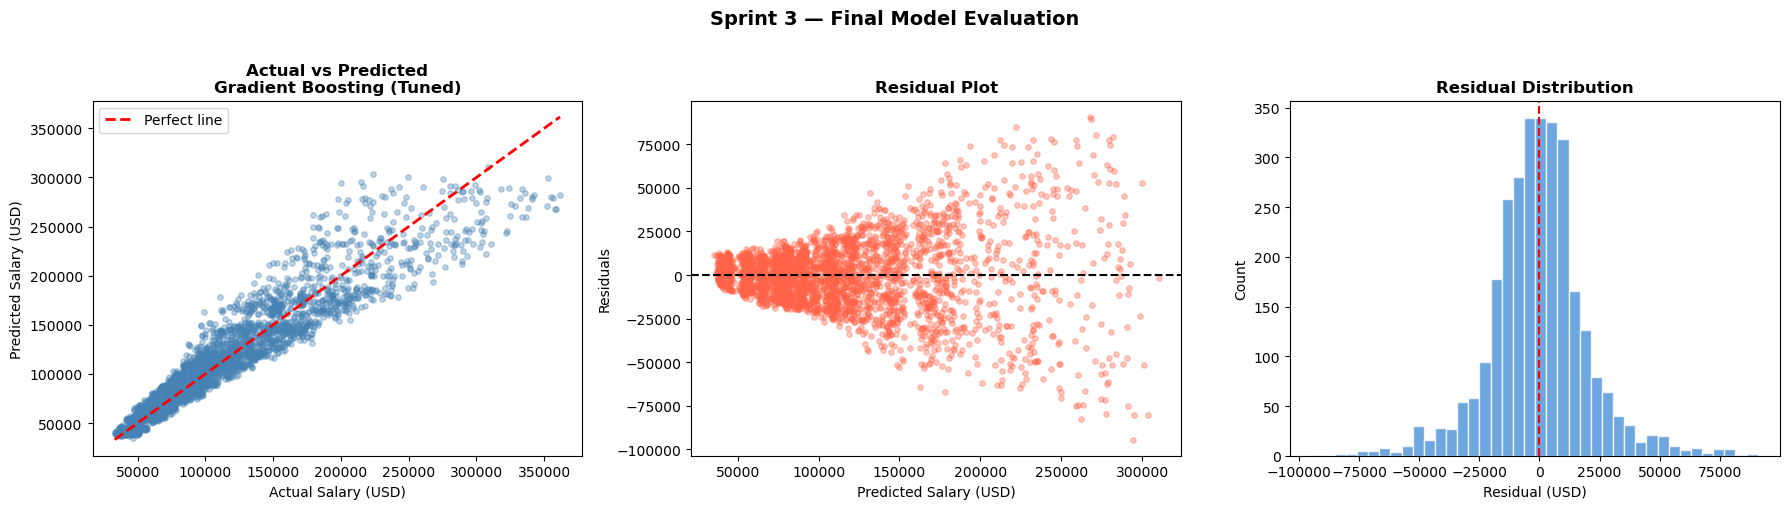

In [27]:
y_pred_final = final_model.predict(X_test_best)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred_final, alpha=0.35, color='steelblue', s=15)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect line')
axes[0].set_title(f'Actual vs Predicted\n{best_tuned_name}', fontweight='bold')
axes[0].set_xlabel('Actual Salary (USD)')
axes[0].set_ylabel('Predicted Salary (USD)')
axes[0].legend()

# 2. Residual Plot
residuals = y_test.values - y_pred_final
axes[1].scatter(y_pred_final, residuals, alpha=0.35, color='tomato', s=15)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Plot', fontweight='bold')
axes[1].set_xlabel('Predicted Salary (USD)')
axes[1].set_ylabel('Residuals')

# 3. Residual Distribution
axes[2].hist(residuals, bins=40, color='#4A90D9', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('Residual Distribution', fontweight='bold')
axes[2].set_xlabel('Residual (USD)')
axes[2].set_ylabel('Count')

plt.suptitle(f'Sprint 3 — Final Model Evaluation', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Cross-validation on final model (5-fold)

In [28]:
cv_scores = cross_val_score(final_model, X_train_best, y_train,
                             cv=5, scoring='r2', n_jobs=-1)

print('-'*50)
print('  5-FOLD CROSS-VALIDATION RESULTS')
print('-'*50)
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: R² = {s:.4f}')
print(f'  Mean R² : {cv_scores.mean():.4f}')
print(f'  Std  R² : ±{cv_scores.std():.4f}')
print('-'*50)
print(f'  Test R² : {final_result["Test R²"]}')
print('CV Mean ≈ Test R² means model generalises well ')

--------------------------------------------------
  5-FOLD CROSS-VALIDATION RESULTS
--------------------------------------------------
  Fold 1: R² = 0.8859
  Fold 2: R² = 0.8838
  Fold 3: R² = 0.8793
  Fold 4: R² = 0.8857
  Fold 5: R² = 0.8863
  Mean R² : 0.8842
  Std  R² : ±0.0026
--------------------------------------------------
  Test R² : 0.8847
CV Mean ≈ Test R² means model generalises well 


# Step 6: Model Serialization


> Save the final model so it can be loaded later for predictions — no retraining needed.

| Format | Use case |
|--------|----------|
| `.pkl` | General Python serialization |
| `.joblib` | Faster for large NumPy arrays (recommended for sklearn) |


In [29]:
import pickle, os

save_dir = '/Users/rezwanshehik/Downloads/'
os.makedirs(save_dir, exist_ok=True)

# Save with joblib (recommended)
joblib_path = save_dir + 'final_model_sprint3.joblib'
joblib.dump(final_model, joblib_path)
print(f'✅ Model saved as joblib : {joblib_path}')

# Save with pickle
pkl_path = save_dir + 'final_model_sprint3.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(final_model, f)
print(f'✅ Model saved as pkl    : {pkl_path}')

# Save the selected feature list
feature_path = save_dir + 'best_features_sprint3.csv'
pd.Series(best_features, name='feature').to_csv(feature_path, index=False)
print(f'✅ Feature list saved    : {feature_path}')

✅ Model saved as joblib : /Users/rezwanshehik/Downloads/final_model_sprint3.joblib
✅ Model saved as pkl    : /Users/rezwanshehik/Downloads/final_model_sprint3.pkl
✅ Feature list saved    : /Users/rezwanshehik/Downloads/best_features_sprint3.csv


In [30]:
# ── Load & verify saved model ────────────────────────────────────────
loaded_model = joblib.load(save_dir + 'final_model_sprint3.joblib')
y_verify     = loaded_model.predict(X_test_best)
r2_verify    = r2_score(y_test, y_verify)

print(f'✅ Model loaded & verified!')
print(f'   Loaded model Test R² : {r2_verify:.4f}')
print(f'   Original  Test R²    : {final_result["Test R²"]}')
assert abs(r2_verify - final_result['Test R²']) < 1e-6, '❌ Mismatch!'
print(f'   Results match ✅')

✅ Model loaded & verified!
   Loaded model Test R² : 0.8847
   Original  Test R²    : 0.8847
   Results match ✅


---
# ✅ Sprint 3 Addition: Save Final Model + Best Features for Pipeline
> The pipeline in Sprint 4 needs the final model AND the exact list of features it was trained on.


In [31]:
import joblib, json as _json, os

save_dir = '/Users/rezwanshehik/Downloads/'
os.makedirs(save_dir, exist_ok=True)

# 1. Save final tuned model
joblib.dump(final_model, save_dir + 'final_model_sprint3.joblib')
print(f'✅ Final model saved   → {save_dir}final_model_sprint3.joblib')
print(f'   Model type : {type(final_model).__name__}')

# 2. Save best feature list used to train final model
with open(save_dir + 'best_features_sprint3.json', 'w') as fp:
    _json.dump(best_features, fp)
print(f'✅ Best features saved  → {save_dir}best_features_sprint3.json')
print(f'   Features ({len(best_features)}): {best_features}')

# 3. Verify round-trip
loaded = joblib.load(save_dir + 'final_model_sprint3.joblib')
from sklearn.metrics import r2_score
r2_check = r2_score(y_test, loaded.predict(X_test_best))
print(f'\n✅ Verification — loaded model Test R² : {r2_check:.4f}')
print(f'   (should match) original Test R²     : {final_result["Test R²"]}')


✅ Final model saved   → /Users/rezwanshehik/Downloads/final_model_sprint3.joblib
   Model type : GradientBoostingRegressor
✅ Best features saved  → /Users/rezwanshehik/Downloads/best_features_sprint3.json
   Features (20): ['job_title', 'salary_currency', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'education_required', 'years_experience', 'industry', 'job_description_length', 'benefits_score', 'application_duration', 'posting_month', 'posting_year', 'posting_day', 'day_of_week', 'days_to_apply', 'skills_count']

✅ Verification — loaded model Test R² : 0.8847
   (should match) original Test R²     : 0.8847


### Sprint 3 now outputs:
| File | Used in Sprint 4 |
|------|------------------|
| `final_model_sprint3.joblib` | Loaded into pipeline |
| `best_features_sprint3.json` | Tells pipeline which columns to pass |
